# 04. 퍼널 EDA (세션 · 동일 상품)

## 분석 개요

- 목적: view → cart → purchase의 strict 순차 퍼널을 세션과 세션·상품 단위로 나누어 도달·전환·이탈을 확인한다.
- 방침 원천: docs/metrics.md(단일 원천). 이 노트북은 방침을 변경하지 않는다.
- 데이터 소스: 분석 집계는 mart_session·mart_session_product·mart_product만 소비한다. raw(events)는 mart_product 생성·검증에서만 사용한다.
- 분석 단위: §1-§4는 세션, §5는 상품 마트 생성·검증, §6은 세션·상품(session-product)이다.
- 순차 기준: 대표값은 strict(event_time < event_time)이다. 분자는 항상 직전 단계 분모의 부분집합이며, 동일 시각 inclusive 결과는 02 민감도 검증으로만 남긴다.
- 경계 처리: 선행 view가 없는 cart·purchase와 순서가 확인되지 않는 경로는 버리지 않고 선형 퍼널 밖 경로로 별도 집계한다. first_event_type은 판정에 사용하지 않는다.
- 범위: 같은 세션 안의 순차 퍼널까지만 다룬다. 세션 경계를 넘는 user×product 여정은 05 소관이다.
- 참고: 결론의 모든 수치는 셀 실행 출력에서 재현하며, 관찰 결과를 인과관계로 해석하지 않는다.

In [1]:
import os
import re
import time
from pathlib import Path
from urllib.parse import quote_plus

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{quote_plus(os.getenv('DB_PASSWORD'))}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}?charset=utf8mb4"
)

color_map = {
    'view': '#3B82F6',
    'cart': '#F59E0B',
    'purchase': '#10B981',
    'remove': '#EF4444',
}

In [2]:
def find_sql(name):
    for base in (Path.cwd(), Path.cwd().parent):
        cand = base / 'sql' / name
        if cand.exists():
            return cand
    raise FileNotFoundError(f'sql/{name} 없음 (cwd={Path.cwd()})')

SQL_FILE = find_sql('04_funnel_eda.sql')
CACHE_DIR = SQL_FILE.parent.parent / 'cache'

def load_queries(path):
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(SQL_FILE)

def run(name, refresh=False, **kwargs):
    cache_path = CACHE_DIR / f'{name}.parquet'
    if cache_path.exists() and not refresh:
        try:
            df = pd.read_parquet(cache_path)
            print(f"[{name}] 캐시 로드 · {len(df):,}행")
            return df
        except Exception:
            pass
    t0 = time.time()
    df = pd.read_sql(text(Q[name]), engine, **kwargs)
    elapsed = time.time() - t0
    try:
        CACHE_DIR.mkdir(exist_ok=True)
        df.to_parquet(cache_path, index=False)
        note = '→ 캐시 저장'
    except Exception as e:
        note = f'(캐시 미저장: {type(e).__name__})'
    print(f"[{name}] 실행 {elapsed:.1f}s · {len(df):,}행 {note}")
    return df

def execute(name):
    # DDL 실행용: -- 라인 주석 제거 후 세미콜론 분리
    body = re.sub(r'--[^\n]*', '', Q[name])
    with engine.begin() as conn:
        for stmt in [s for s in body.split(';') if s.strip()]:
            conn.execute(text(stmt))

def add_funnel_rates(df):
    out = df.copy()
    out['view_cart_전환율'] = np.where(
        out['view_도달'] > 0, out['view_cart_순차'] / out['view_도달'] * 100, np.nan
    )
    out['cart_purchase_전환율'] = np.where(
        out['view_cart_순차'] > 0,
        out['view_cart_purchase_순차'] / out['view_cart_순차'] * 100,
        np.nan,
    )
    out['view_purchase_전환율'] = np.where(
        out['view_도달'] > 0,
        out['view_cart_purchase_순차'] / out['view_도달'] * 100,
        np.nan,
    )
    return out

---
## 1. 전체 순차 퍼널 — 3단계 도달·전환 (세션 기준)

분석 단위는 **세션**이다. view 도달 세션을 첫 분모로 두고, 같은 세션에서 view 이후 cart가 확인된 세션과 그 cart 이후 purchase가 확인된 세션을 순서대로 센다. strict 플래그를 사용하므로 각 단계의 분자는 직전 단계 분모의 부분집합이다.

In [3]:
reach = run('fn_session_funnel') # 세션 전체 strict 순차 퍼널 (view, view->cart, view->cart-purchase)
r = reach.iloc[0]
view_d = int(r['view_도달'])
cart_d = int(r['view_cart_순차'])
purchase_d = int(r['view_cart_purchase_순차'])
valid = int(r['유효세션'])

assert purchase_d <= cart_d <= view_d <= valid

funnel = pd.DataFrame({
    '단계': ['view 도달', 'view→cart 순차 도달', 'view→cart→purchase 순차 도달'],
    '세션수': [view_d, cart_d, purchase_d],
})
funnel['전환율_전단계대비'] = [np.nan, cart_d / view_d, purchase_d / cart_d]
funnel['유지율_view대비'] = [1.0, cart_d / view_d, purchase_d / view_d]
funnel['이탈률_1-전환'] = [np.nan, 1 - cart_d / view_d, 1 - purchase_d / cart_d]
funnel['단계간_이탈세션'] = [np.nan, view_d - cart_d, cart_d - purchase_d]

disp = funnel.copy()
for c in ['전환율_전단계대비', '유지율_view대비', '이탈률_1-전환']:
    disp[c] = (disp[c] * 100).round(2)
print(f"유효세션 {valid:,} · view 미도달 {valid - view_d:,}")
disp

[fn_session_funnel] 캐시 로드 · 1행
유효세션 4,499,479 · view 미도달 254,145


,단계,세션수,전환율_전단계대비,유지율_view대비,이탈률_1-전환,단계간_이탈세션
0,view 도달,4245334,NaN,100.00,NaN,NaN
1,view→cart 순차 도달,710008,16.72,16.72,83.28,3535326.0
2,view→cart→purchase 순차 도달,97600,13.75,2.30,86.25,612408.0


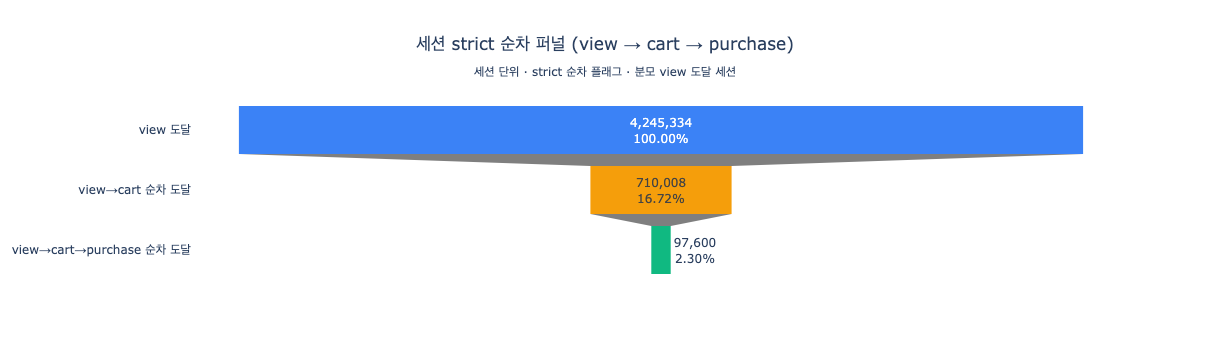

In [4]:
fig = go.Figure(go.Funnel(
    y=funnel['단계'],
    x=funnel['세션수'],
    marker=dict(color=[color_map['view'], color_map['cart'], color_map['purchase']]),
    texttemplate='%{value:,.0f}<br>%{percentInitial:.2%}',
))
fig.update_layout(
    title=dict(
        text='세션 strict 순차 퍼널 (view → cart → purchase)<br>'
             '<sub>세션 단위 · strict 순차 플래그 · 분모 view 도달 세션</sub>',
        x=0.5,
        xanchor='center',
    ),
    plot_bgcolor='white',
)
fig.show()

> ### 섹션 결론
>
> - 유효 세션 4,499,479개 중 view 도달은 4,245,334개(94.35%)다. 이 중 710,008개가 view 이후 cart에 도달해 전 단계 대비 전환율은 **16.72%** 다.
> - view→cart 순차 도달 710,008개 중 97,600개가 이후 purchase까지 도달해 전 단계 대비 전환율은 **13.75%** 다. 최초 view 대비 view→purchase 전환율은 **2.30%** 다.
> - 절대 감소는 view→cart 구간이 3,535,326개로 가장 크고, cart 도달 후에도 612,408개가 순차 purchase에 도달하지 않았다. 두 구간 모두 후속 원인 분석 대상이며, 이 결과는 같은 세션 안의 순서만 반영한다.

---
## 2. 순차 cart 도달 세션의 remove 동반 여부 (세션 기준)

분석 단위는 **세션**이다. cart 순차 도달은 has_cart_after_view=1로 정의한다. removes > 0은 해당 세션 어디선가 remove_from_cart가 1회 이상 존재한다는 뜻이다. 현재 마트에는 remove 시각이 없으므로 remove가 view·cart 사이인지, cart 이후인지, purchase 전후인지 판별하지 않는다. 따라서 이 절은 이탈 판정이 아니라 동일 세션 내 동반 관찰로만 해석한다.

In [5]:
rs = run('fn_remove_signal').iloc[0] # strict cart 순차 도달 세션의 remove 동반 여부
cart_reach = int(rs['view_cart_순차'])
remove_reach = int(rs['순차cart중_제거발생'])
nonpurchase = int(rs['순차cart_미구매'])
nonpurchase_remove = int(rs['순차cart미구매중_제거발생'])
purchase_remove = remove_reach - nonpurchase_remove
remove_tbl = pd.DataFrame({
    '지표': ['view→cart 순차 도달', '순차 cart 도달 세션 중 remove 동반(순서 미반영)',
           '순차 cart 도달 후 순차 purchase 미도달',
           '순차 purchase 미도달 세션 중 remove 동반(순서 미반영)'],
    '세션수': [
        cart_reach,
        remove_reach,
        nonpurchase,
        nonpurchase_remove,
    ],
})
remove_tbl['순차cart세션대비_pct'] = (remove_tbl['세션수'] / cart_reach * 100).round(2)
print(
    f"순차 purchase 미도달 중 remove 동반 = {nonpurchase_remove:,} / {nonpurchase:,} "
    f"({nonpurchase_remove / nonpurchase * 100:.2f}%)"
)
print(
    f"remove 동반 중 순차 purchase 도달 = {purchase_remove:,} / {remove_reach:,} "
    f"({purchase_remove / remove_reach * 100:.2f}%)"
)
remove_tbl

[fn_remove_signal] 캐시 로드 · 1행
순차 purchase 미도달 중 remove 동반 = 224,689 / 612,408 (36.69%)
remove 동반 중 순차 purchase 도달 = 70,928 / 295,617 (23.99%)


,지표,세션수,순차cart세션대비_pct
0,view→cart 순차 도달,710008,100.00
1,순차 cart 도달 세션 중 remove 동반(순서 미반영),295617,41.64
2,순차 cart 도달 후 순차 purchase 미도달,612408,86.25
3,순차 purchase 미도달 세션 중 remove 동반(순서 미반영),224689,31.65


> ### 섹션 결론
>
> - view→cart 순차 도달 710,008세션 중 remove 동반 세션은 295,617개(41.64%)이다.
> - 순차 purchase 미도달 612,408세션 중 remove 동반 세션은 224,689개로, 해당 집단의 36.69%이다.
> - remove 동반 세션 중 70,928개(23.99%)는 순차 purchase에도 도달했다. 현재 removes는 세션 내 발생 여부만 나타내므로 remove를 장바구니 이탈로 해석하지 않고, cart·purchase와의 상세 순서는 05 구매 여정에서 확인한다.

---
## 3. 순차 퍼널 밖 경로 — 직접 진입·순서 미확인 (세션 기준)

분석 단위는 **세션**이다. first_event_type은 전체 이벤트 기준의 기술값이므로 판정에 사용하지 않는다. view 없이 cart·purchase가 관찰된 직접 진입과, view·cart는 모두 있지만 strict 순서가 확인되지 않은 경로를 카운트와 순차 플래그로 집계한다. 각 조건은 독립 집계이므로 서로 겹칠 수 있다. `view·cart 있으나 strict 순서 미확인`에는 cart가 view보다 먼저인 경로와 동일 시각 경계가 함께 포함된다. 동일 시각을 인정하면 view→cart가 643세션 증가하므로 이 버킷 전체를 역순 행동으로 해석하지 않는다.

In [6]:
b = run('fn_boundary').iloc[0] # view → cart → purchase 순서와 다른 세션 규모
boundary_tbl = pd.DataFrame({
    '구분': [
        'view 없이 cart',
        'view 없이 purchase',
        'view·cart 있으나 strict 순서 미확인',
        'purchase 있으나 순차 purchase 아님',
        'cart·purchase 없이 remove 존재',
        'view 미도달 전체',
    ],
    '세션수': [
        int(b['view없이_cart']),
        int(b['view없이_purchase']),
        int(b['view_cart있으나_순서미확인']),
        int(b['purchase있으나_순차purchase아님']),
        int(b['cart없는_제거세션']),
        int(b['view_미도달_전체']),
    ],
})
boundary_tbl['유효세션대비_pct'] = (
    boundary_tbl['세션수'] / int(b['유효세션']) * 100
).round(3)
print(
    f"cart·purchase 없이 remove 존재 = {int(b['cart없는_제거세션']):,} "
    f"(03 reach_residual 87,927와 정합: {int(b['cart없는_제거세션']) == 87927})"
)
boundary_tbl

[fn_boundary] 캐시 로드 · 1행
cart·purchase 없이 remove 존재 = 87,927 (03 reach_residual 87,927와 정합: True)


,구분,세션수,유효세션대비_pct
0,view 없이 cart,196424,4.365
1,view 없이 purchase,39015,0.867
2,view·cart 있으나 strict 순서 미확인,63525,1.412
3,purchase 있으나 순차 purchase 아님,864,0.019
4,cart·purchase 없이 remove 존재,87927,1.954
5,view 미도달 전체,254145,5.648


> ### 섹션 결론
>
> - view 없이 cart가 관찰된 세션은 196,424개(유효 세션의 4.365%), view 없이 purchase가 관찰된 세션은 39,015개(0.867%)로, view부터 시작하는 선형 퍼널만으로 설명되지 않는 경로가 존재한다.
> - view와 cart가 모두 있지만 strict 순서가 확인되지 않은 세션은 63,525개(1.412%)이다. 이 중 동일 시각을 인정할 때 추가되는 643세션이 포함되므로 전체를 cart→view 역순으로 간주할 수 없다.
> - cart·purchase 없이 remove만 관찰된 세션은 87,927개(1.954%)다. 이전 세션에서 담은 장바구니 상태가 유지됐을 가능성을 시사해 세션 단위 분석이 놓치는 상태의 근거가 되지만, cart 로깅 누락이나 추적 유실 가능성도 배제할 수 없다.
> - 각 조건은 서로 겹칠 수 있고 세션 경계를 넘는 선행 행동을 포함하지 않으므로 합산하지 않는다. 직접 진입·지연 구매·장바구니 상태의 연결은 05에서 사용자·상품 단위로 확인한다.

---
## 4. 세그먼트별 strict 순차 퍼널 (세션 기준)

분석 단위는 **세션**이다. 요일·월(session_start), total_events, 탐색 깊이(views), 사용자당 관측 세션 수별로 strict 순차 도달과 전환율을 비교한다. total_events는 퍼널 이벤트를 포함하므로 미전환 세션 분해에만 사용하고, 탐색 깊이는 상류 지표인 views로 별도 확인한다. 1세션·2+세션 구분은 관측 기간 내 사용자 분류이며 신규 여부나 개별 세션의 방문 차수를 뜻하지 않는다. 모든 전환율은 순차 플래그로 계산하므로 100%를 넘지 않는다.

### 요일별

In [7]:
dow = add_funnel_rates(run('fn_seg_dow')) # 요일별 strict 순차 퍼널
dow_names = {1: '일', 2: '월', 3: '화', 4: '수', 5: '목', 6: '금', 7: '토'}
dow['요일'] = dow['요일번호'].map(dow_names)
dow_show = [
    '요일', 'view_도달', 'view_cart_순차', 'view_cart_purchase_순차', '세션수',
    'view_cart_전환율', 'cart_purchase_전환율', 'view_purchase_전환율',
]
dow[dow_show].round(2)

[fn_seg_dow] 캐시 로드 · 7행


,요일,view_도달,view_cart_순차,view_cart_purchase_순차,세션수,view_cart_전환율,cart_purchase_전환율,view_purchase_전환율
0,일,561531.0,100969.0,12427.0,593291,17.98,12.31,2.21
1,월,621053.0,106517.0,14442.0,659296,17.15,13.56,2.33
2,화,629070.0,104274.0,14692.0,666485,16.58,14.09,2.34
3,수,642297.0,115775.0,14344.0,680334,18.03,12.39,2.23
4,목,634562.0,102263.0,15316.0,674514,16.12,14.98,2.41
5,금,609093.0,95497.0,14551.0,646029,15.68,15.24,2.39
6,토,547728.0,84713.0,11828.0,579530,15.47,13.96,2.16


### 월별

session_start가 속한 월을 기준으로 strict 순차 퍼널을 비교한다. 양끝 월의 관측 시작·종료일과 관측 일수를 먼저 확인해 부분 월 여부를 판정한다. 01에서 price=0 이벤트가 집중된 2020-02의 지표가 다른 월과 함께 어떻게 움직이는지 확인하되, 품질 신호와 전환율 변화의 인과관계는 가정하지 않는다.

In [8]:
monthly = add_funnel_rates(run('fn_seg_month')) # 월별 strict 순차 퍼널과 관측 범위
monthly['관측시작'] = pd.to_datetime(monthly['관측시작'])
monthly['관측종료'] = pd.to_datetime(monthly['관측종료'])
monthly['달력일수'] = pd.PeriodIndex(monthly['월'], freq='M').days_in_month
monthly['부분월'] = (
    (monthly['관측시작'].dt.day != 1)
    | (monthly['관측종료'].dt.day != monthly['달력일수'])
    | (monthly['관측일수'] != monthly['달력일수'])
)
monthly_rates_valid = monthly[[
    'view_cart_전환율', 'cart_purchase_전환율', 'view_purchase_전환율',
]].stack().between(0, 100).all()
assert monthly_rates_valid
month_range_cols = ['월', '세션수', '관측시작', '관측종료', '관측일수', '달력일수', '부분월']
print('--- 양끝 월 관측 범위 ---')
display(monthly.iloc[[0, -1]][month_range_cols])
month_show = [
    '월', '세션수', 'view_도달', 'view_cart_순차', 'view_cart_purchase_순차',
    'view_cart_전환율', 'cart_purchase_전환율', 'view_purchase_전환율',
]
display(monthly[month_show].round(3))
monthly_spread = pd.DataFrame([
    {
        '단계': label, '최솟값': monthly[col].min(), '최댓값': monthly[col].max(),
        '최대_최소배율': monthly[col].max() / monthly[col].min(),
    }
    for col, label in [
        ('view_cart_전환율', 'view→cart'),
        ('cart_purchase_전환율', 'cart→purchase'),
        ('view_purchase_전환율', 'view→purchase'),
    ]
])
print('--- 월별 단계 전환율 변동 폭(%) ---')
monthly_spread.round(3)

[fn_seg_month] 캐시 로드 · 5행
--- 양끝 월 관측 범위 ---


,월,세션수,관측시작,관측종료,관측일수,달력일수,부분월
0,2019-10,865774,2019-10-01 00:00:00,2019-10-31 23:59:54,31,31,False
4,2020-02,916482,2020-02-01 00:00:03,2020-02-29 23:59:28,29,29,False


,월,세션수,view_도달,view_cart_순차,view_cart_purchase_순차,view_cart_전환율,cart_purchase_전환율,view_purchase_전환율
0,2019-10,865774,818254.0,174591.0,18429.0,21.337,10.556,2.252
1,2019-11,932387,874437.0,150182.0,22675.0,17.175,15.098,2.593
2,2019-12,831007,785944.0,115867.0,18164.0,14.742,15.677,2.311
3,2020-01,953829,901960.0,138219.0,20058.0,15.324,14.512,2.224
4,2020-02,916482,864739.0,131149.0,18274.0,15.166,13.934,2.113


--- 월별 단계 전환율 변동 폭(%) ---


,단계,최솟값,최댓값,최대_최소배율
0,view→cart,14.742,21.337,1.447
1,cart→purchase,10.556,15.677,1.485
2,view→purchase,2.113,2.593,1.227


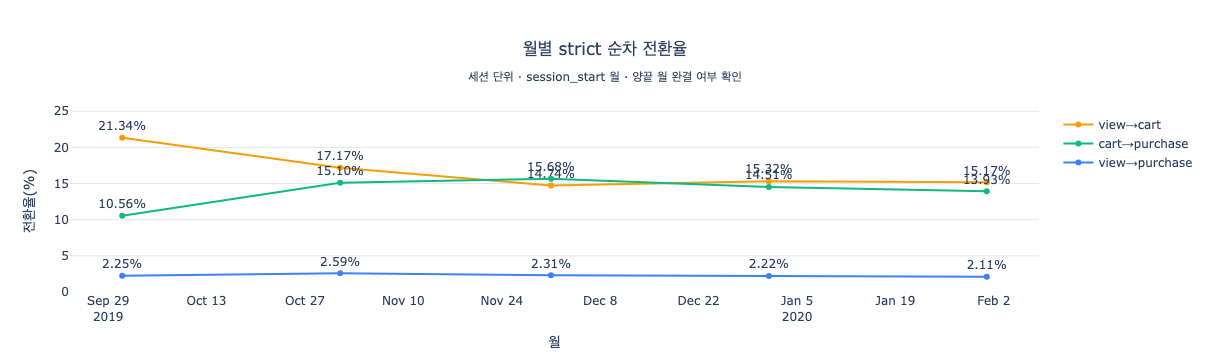

In [9]:
fig = go.Figure()
for col, label, color in [
    ('view_cart_전환율', 'view→cart', color_map['cart']),
    ('cart_purchase_전환율', 'cart→purchase', color_map['purchase']),
    ('view_purchase_전환율', 'view→purchase', color_map['view']),
]:
    fig.add_trace(go.Scatter(
        x=monthly['월'], y=monthly[col], mode='lines+markers+text', name=label,
        line=dict(color=color), text=monthly[col].map(lambda x: f'{x:.2f}%'),
        textposition='top center', cliponaxis=False,
    ))
monthly_rate_max = monthly[[
    'view_cart_전환율', 'cart_purchase_전환율', 'view_purchase_전환율',
]].to_numpy().max()
fig.update_layout(
    title=dict(
        text='월별 strict 순차 전환율<br><sub>세션 단위 · session_start 월 · 양끝 월 완결 여부 확인</sub>',
        x=0.5, xanchor='center',
    ),
    xaxis_title='월', yaxis_title='전환율(%)', plot_bgcolor='white',
    yaxis=dict(range=[0, monthly_rate_max * 1.18], gridcolor='#E5E7EB'),
    margin=dict(t=110, r=40, b=60, l=70),
)
fig.show()

### 세션당 이벤트 수(total_events)별

In [10]:
seg_e = add_funnel_rates(run('fn_seg_events')) # 세션당 total_events 구간별 strict 순차 퍼널
seg_e['view_cart_미전환'] = seg_e['view_도달'] - seg_e['view_cart_순차']
total_view_cart_drop = int(seg_e['view_cart_미전환'].sum())
single_event_drop = int(seg_e.loc[seg_e['구간'] == '0-1', 'view_cart_미전환'].iloc[0])
multi_event_drop = total_view_cart_drop - single_event_drop
seg_e['전체_view_cart_미전환대비_pct'] = (
    seg_e['view_cart_미전환'] / total_view_cart_drop * 100
)
print(
    f"view→cart 미전환 {total_view_cart_drop:,}세션 중 "
    f"0-1 이벤트 구간 {single_event_drop:,}세션"
    f"({single_event_drop / total_view_cart_drop * 100:.2f}%) · "
    f"2+ 이벤트 구간 {multi_event_drop:,}세션"
    f"({multi_event_drop / total_view_cart_drop * 100:.2f}%)"
)
seg_e.round(2)

[fn_seg_events] 캐시 로드 · 5행
view→cart 미전환 3,535,326세션 중 0-1 이벤트 구간 2,819,440세션(79.75%) · 2+ 이벤트 구간 715,886세션(20.25%)


,구간,view_도달,view_cart_순차,view_cart_purchase_순차,세션수,view_cart_전환율,cart_purchase_전환율,view_purchase_전환율,view_cart_미전환,전체_view_cart_미전환대비_pct
0,0-1,2819440.0,0.0,0.0,2887065,0.00,NaN,0.00,2819440.0,79.75
1,2-3,631534.0,160626.0,2090.0,695651,25.43,1.30,0.33,470908.0,13.32
2,4-10,444667.0,250995.0,19466.0,518952,56.45,7.76,4.38,193672.0,5.48
3,11-50,301720.0,252987.0,59295.0,345883,83.85,23.44,19.65,48733.0,1.38
4,51+,47973.0,45400.0,16749.0,51928,94.64,36.89,34.91,2573.0,0.07


### 탐색 깊이(views)별

분석 단위는 **view 도달 세션**이다. views는 cart·purchase를 포함하지 않는 상류 노출 횟수이므로 total_events보다 단계 간 산술 결합이 작다. views 구간별 view→cart 순차 전환율이 단조 상승하는지, 특정 구간 이후 낮아지는지 확인한다.

In [11]:
seg_views = run('fn_seg_views') # view 횟수 구간별 strict view→cart 전환
seg_views['view_cart_전환율'] = seg_views['view_cart_순차'] / seg_views['세션수'] * 100
seg_views['view_cart_미전환'] = seg_views['세션수'] - seg_views['view_cart_순차']

assert seg_views['view_cart_전환율'].between(0, 100).all()

views_monotonic = seg_views['view_cart_전환율'].is_monotonic_increasing
deep = seg_views[seg_views['구간'].isin(['11-30', '31+'])]
deep_no_cart = int(deep['view_cart_미전환'].sum())
single_event_view = int(seg_e.loc[seg_e['구간'] == '0-1', 'view_도달'].iloc[0])

v1 = seg_views.loc[seg_views['구간'] == '1'].iloc[0]
v1_sessions, v1_cart = int(v1['세션수']), int(v1['view_cart_순차'])
v1_multi = v1_sessions - single_event_view

assert 0 < v1_multi <= v1_sessions and v1_cart <= v1_multi

print(f"views 구간별 view→cart 전환율 단조 상승: {views_monotonic}")
print(f"views 11회 이상·순차 cart 미도달 세션: {deep_no_cart:,}")
print(
    f"views=1 구성: 단일 이벤트 {single_event_view:,} / {v1_sessions:,} "
    f"({single_event_view / v1_sessions * 100:.2f}%) · "
    f"다중 이벤트 {v1_multi:,} ({v1_multi / v1_sessions * 100:.2f}%)"
)
print(
    f"views=1 다중 이벤트 세션의 순차 cart 도달 = {v1_cart:,} / {v1_multi:,} "
    f"({v1_cart / v1_multi * 100:.2f}%)"
)
seg_views.round(3)

[fn_seg_views] 캐시 로드 · 5행
views 구간별 view→cart 전환율 단조 상승: True
views 11회 이상·순차 cart 미도달 세션: 24,729
views=1 구성: 단일 이벤트 2,819,440 / 3,147,952 (89.56%) · 다중 이벤트 328,512 (10.44%)
views=1 다중 이벤트 세션의 순차 cart 도달 = 265,405 / 328,512 (80.79%)


,구간,세션수,view_cart_순차,view_cart_전환율,view_cart_미전환
0,1,3147952,265405.0,8.431,2882547.0
1,2-3,631264,164777.0,26.103,466487.0
2,4-10,341458,179895.0,52.684,161563.0
3,11-30,105504,82983.0,78.654,22521.0
4,31+,19156,16948.0,88.474,2208.0


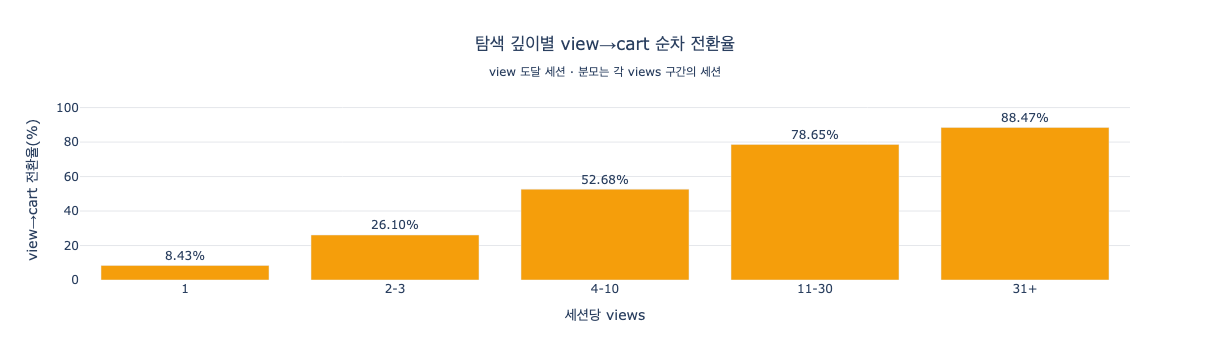

In [12]:
views_rate_max = seg_views['view_cart_전환율'].max()

fig = go.Figure(go.Bar(
    x=seg_views['구간'],
    y=seg_views['view_cart_전환율'],
    marker_color=color_map['cart'],
    text=seg_views['view_cart_전환율'].map(lambda x: f'{x:.2f}%'),
    textposition='outside',
))
fig.update_layout(
    title=dict(
        text='탐색 깊이별 view→cart 순차 전환율<br><sub>view 도달 세션 · 분모는 각 views 구간의 세션</sub>',
        x=0.5, xanchor='center',
    ),
    xaxis_title='세션당 views', yaxis_title='view→cart 전환율(%)',
    yaxis=dict(gridcolor='#E5E7EB', range=[0, views_rate_max * 1.18]),
    plot_bgcolor='white', 
)
fig.show()

### 사용자당 관측 세션 수별

In [13]:
seg_v = add_funnel_rates(run('fn_seg_visit')) # 사용자당 관측 세션 수별 strict 순차 퍼널
total_users = int(seg_v['사용자수'].sum())
repeat_row = seg_v.loc[seg_v['세그먼트'] == '2+세션 사용자'].iloc[0]
repeat_user_share = int(repeat_row['사용자수']) / total_users * 100
repeat_session_share = int(repeat_row['세션수']) / int(seg_v['세션수'].sum()) * 100
repeat_purchase_share = (
    int(repeat_row['view_cart_purchase_순차'])
    / int(seg_v['view_cart_purchase_순차'].sum()) * 100
)
print(
    f"2+세션 사용자 = {int(repeat_row['사용자수']):,} / {total_users:,} "
    f"({repeat_user_share:.2f}%)"
)
print(
    f"2+세션 사용자 집단의 세션 점유 = {int(repeat_row['세션수']):,} / "
    f"{int(seg_v['세션수'].sum()):,} ({repeat_session_share:.2f}%)"
)
print(
    f"2+세션 사용자 집단의 순차 구매 세션 점유 = "
    f"{int(repeat_row['view_cart_purchase_순차']):,} / "
    f"{int(seg_v['view_cart_purchase_순차'].sum()):,} ({repeat_purchase_share:.2f}%)"
)
seg_v.round(2)

[fn_seg_visit] 캐시 로드 · 2행
2+세션 사용자 = 550,276 / 1,633,876 (33.68%)
2+세션 사용자 집단의 세션 점유 = 3,415,879 / 4,499,479 (75.92%)
2+세션 사용자 집단의 순차 구매 세션 점유 = 80,968 / 97,600 (82.96%)


,세그먼트,사용자수,view_도달,view_cart_순차,view_cart_purchase_순차,세션수,view_cart_전환율,cart_purchase_전환율,view_purchase_전환율
0,1세션 사용자,1083600,1045856.0,127573.0,16632.0,1083600,12.2,13.04,1.59
1,2+세션 사용자,550276,3199478.0,582435.0,80968.0,3415879,18.2,13.90,2.53


In [14]:
segment_rate_cols = [
    'view_cart_전환율', 'cart_purchase_전환율', 'view_purchase_전환율',
]
segment_rates_valid = all(
    frame[segment_rate_cols].stack().between(0, 100).all()
    for frame in (dow, seg_e, seg_v)
)
print(f"세그먼트 strict 전환율 0~100% 검증: {segment_rates_valid}")
assert segment_rates_valid

세그먼트 strict 전환율 0~100% 검증: True


> ### 섹션 결론
>
> - 양끝 월인 2019-10과 2020-02는 각각 31일·29일이 모두 관측된 완결 월이다. 01에서 price=0 급증이 관찰된 2020-02의 view→cart·cart→purchase·view→purchase는 15.166%·13.934%·2.113%였으며, 이 품질 신호와 퍼널 변동의 인과관계는 확인되지 않는다. 2019-10은 21.337%·10.556%·2.252%, 2019-12는 14.742%·15.677%·2.311%로 중간 두 단계가 반대 방향으로 움직였지만 최종 전환은 유사했다. 5개월 view→purchase도 2.113%-2.593%(1.227배)로 세 단계 중 상대적 변동 폭이 가장 좁았다.
> - view→cart 미전환 3,535,326세션 중 2,819,440개(79.75%)는 유효 이벤트가 view 1개뿐이며, 나머지 715,886개(20.25%)는 2개 이상 이벤트가 있다. views=1 구간에서도 단일 이벤트 세션이 2,819,440 / 3,147,952(89.56%)를 차지하고, 나머지 다중 이벤트 세션의 순차 cart 도달은 265,405 / 328,512(80.79%)다. 따라서 views=1 전체 전환율 8.431%는 성격이 다른 두 집단이 섞인 비율이다.
> - views 구간별 view→cart 전환율은 8.431%-88.474%로 단조 상승해 특정 구간 이후 하락은 관찰되지 않았다. 다만 이 패턴을 탐색 깊이의 효과로 해석하지 않으며, views 11회 이상에서도 순차 cart에 도달하지 않은 24,729세션만 상품 탐색·UI 진단 후보로 둔다.
> - 2+세션 사용자는 전체 1,633,876명 중 550,276명(33.68%)이지만 전체 세션의 75.92%(3,415,879 / 4,499,479), 순차 구매 세션의 82.96%(80,968 / 97,600)를 차지했다. 관측 기간 내 소수 사용자 집단에 활동과 순차 구매가 집중된 결과이며, 재방문의 인과 효과를 뜻하지 않는다.

---
## 5. 상품 마트 생성·검증 (상품 기준)

분석 단위는 **상품(product_id)** 이다. mart_product는 상품별 category_id·brand·avg_price 속성과 기존 요약값을 제공한다. category_id와 brand는 최빈값을 사용하고, 동률이면 최종 관찰 시각 내림차순과 값 오름차순으로 대표값을 정한다. 유효한 brand가 없는 상품은 unknown으로 보존한다. raw(events)는 이 마트의 생성·검증에서만 사용한다. 반복 실행에서는 기존 mart_product를 사용하고 생성·검증을 생략하며, 생성 SQL이나 raw가 변경된 경우에는 `REBUILD_MART_PRODUCT`와 `RUN_PRODUCT_MART_VALIDATION`을 모두 `True`로 바꾼다.

In [15]:
REBUILD_MART_PRODUCT = False  # 생성 SQL·raw 변경 시에만 True
RUN_PRODUCT_MART_VALIDATION = False  # 재생성·정합성 재확인 시에만 True

if REBUILD_MART_PRODUCT and not RUN_PRODUCT_MART_VALIDATION:
    raise ValueError('마트 재생성 시 RUN_PRODUCT_MART_VALIDATION도 True여야 합니다.')

if REBUILD_MART_PRODUCT:
    t0 = time.time()
    execute('create_mart_product')
    product_build_sec = time.time() - t0
    print(f"mart_product 재생성 완료 · {product_build_sec:.0f}s")
else:
    print('기존 mart_product 사용')

기존 mart_product 사용


### 검증 a — 상품 수

In [16]:
if RUN_PRODUCT_MART_VALIDATION:
    mart_n = int(run('prod_mart_count', refresh=False).iloc[0, 0])
    raw_n = int(run('prod_raw_count', refresh=False).iloc[0, 0])
    print(f"마트 상품 수 = {mart_n:,}")
    print(f"raw 상품 수  = {raw_n:,}")
    print(f"일치: {mart_n == raw_n}")
else:
    print('검증a 생략 · RUN_PRODUCT_MART_VALIDATION=False')

검증a 생략 · RUN_PRODUCT_MART_VALIDATION=False


### 검증 b — 유형별 카운트 합

In [17]:
if RUN_PRODUCT_MART_VALIDATION:
    mart_c = run('prod_mart_type', refresh=False).iloc[0]
    raw_c = run('prod_raw_type', refresh=False).set_index('event_type')['건수']
    order = ['view', 'cart', 'purchase']
    cmp_b = pd.DataFrame({
        'mart': [int(mart_c[t]) for t in order],
        'raw': [int(raw_c[t]) for t in order],
    }, index=order)
    cmp_b['일치'] = cmp_b['mart'] == cmp_b['raw']
    display(cmp_b)
else:
    print('검증b 생략 · RUN_PRODUCT_MART_VALIDATION=False')

검증b 생략 · RUN_PRODUCT_MART_VALIDATION=False


### 검증 c-d — revenue·마트 연결·대표 속성 방침

In [18]:
if RUN_PRODUCT_MART_VALIDATION:
    mart_r = float(run('prod_mart_revenue', refresh=False).iloc[0, 0])
    raw_r = float(run('prod_raw_revenue', refresh=False).iloc[0, 0])
    join_check = run('prod_join_check', refresh=False).iloc[0]
    attribute_quality = run('prod_attribute_quality', refresh=False).iloc[0]

    print(f"마트 revenue = {mart_r:,.2f}")
    print(f"raw revenue  = {raw_r:,.2f}")
    print(f"revenue 일치: {round(mart_r, 2) == round(raw_r, 2)}")
    print(f"session-product = {int(join_check['session_product수']):,}")
    print(f"상품 속성 미연결 = {int(join_check['상품속성_미연결']):,}")
    print(f"다중 category_id 상품 = {int(attribute_quality['다중category_상품']):,}")
    print(f"다중 brand 상품 = {int(attribute_quality['다중brand_상품']):,}")
    print(f"brand unknown 상품 = {int(attribute_quality['brand_unknown_상품']):,}")
else:
    print('검증c-e 생략 · RUN_PRODUCT_MART_VALIDATION=False')

검증c-e 생략 · RUN_PRODUCT_MART_VALIDATION=False


### 검증 종합 (게이트)

In [19]:
if RUN_PRODUCT_MART_VALIDATION:
    check_a = mart_n == raw_n
    check_b = bool(cmp_b['일치'].all())
    check_c = round(mart_r, 2) == round(raw_r, 2)
    check_d = (
        int(attribute_quality['product_id_NULL']) == 0
        and int(attribute_quality['category_대표값오류']) == 0
        and int(attribute_quality['brand_대표값오류']) == 0
    )
    check_e = int(join_check['상품속성_미연결']) == 0
    product_gate = check_a and check_b and check_c and check_d and check_e

    print(f"검증a(상품 수): {check_a}")
    print(f"검증b(유형별 카운트): {check_b}")
    print(f"검증c(revenue): {check_c}")
    print(f"검증d(상품 대표 속성 방침): {check_d}")
    print(f"검증e(session-product 연결): {check_e}")
    print(f"전체 통과(gate): {product_gate}")
    assert product_gate, '검증 실패 — 양쪽 수치 확인 후 §6 진행 중단'
else:
    required_cache = [
        'prod_mart_count', 'prod_raw_count', 'prod_mart_type', 'prod_raw_type',
        'prod_mart_revenue', 'prod_raw_revenue', 'prod_join_check',
        'prod_attribute_quality',
    ]
    missing_cache = [name for name in required_cache if not (CACHE_DIR / f'{name}.parquet').exists()]
    if missing_cache:
        raise FileNotFoundError(
            f"검증 캐시 없음: {missing_cache}. RUN_PRODUCT_MART_VALIDATION=True로 실행하세요."
        )
    cached = {name: pd.read_parquet(CACHE_DIR / f'{name}.parquet') for name in required_cache}
    cached_mart_n = int(cached['prod_mart_count'].iloc[0, 0])
    cached_raw_n = int(cached['prod_raw_count'].iloc[0, 0])
    cached_mart_r = float(cached['prod_mart_revenue'].iloc[0, 0])
    cached_raw_r = float(cached['prod_raw_revenue'].iloc[0, 0])
    cached_mart_type = cached['prod_mart_type'].iloc[0]
    cached_raw_type = cached['prod_raw_type'].set_index('event_type')['건수']
    cached_type_match = all(
        int(cached_mart_type[t]) == int(cached_raw_type[t])
        for t in ['view', 'cart', 'purchase']
    )
    cached_join = cached['prod_join_check'].iloc[0]
    cached_quality = cached['prod_attribute_quality'].iloc[0]
    product_gate = (
        cached_mart_n == cached_raw_n
        and cached_type_match
        and round(cached_mart_r, 2) == round(cached_raw_r, 2)
        and int(cached_join['상품속성_미연결']) == 0
        and int(cached_quality['product_id_NULL']) == 0
        and int(cached_quality['category_대표값오류']) == 0
        and int(cached_quality['brand_대표값오류']) == 0
    )
    print('raw 재검증 생략 · 마지막 검증 캐시 요약')
    print(f"마트·raw 상품 수 = {cached_mart_n:,} · {cached_raw_n:,}")
    print(f"view·cart·purchase 합계 일치 = {cached_type_match}")
    print(f"마트·raw revenue = {cached_mart_r:,.2f} · {cached_raw_r:,.2f}")
    print(f"session-product = {int(cached_join['session_product수']):,}")
    print(f"상품 속성 미연결 = {int(cached_join['상품속성_미연결']):,}")
    print(f"다중 category_id 상품 = {int(cached_quality['다중category_상품']):,}")
    print(f"다중 brand 상품 = {int(cached_quality['다중brand_상품']):,}")
    print(f"brand unknown 상품 = {int(cached_quality['brand_unknown_상품']):,}")
    print(f"마지막 검증 캐시 정합성: {product_gate}")

raw 재검증 생략 · 마지막 검증 캐시 요약
마트·raw 상품 수 = 54,566 · 54,566
view·cart·purchase 합계 일치 = True
마트·raw revenue = 6,351,830.29 · 6,351,830.29
session-product = 12,102,048
상품 속성 미연결 = 0
다중 category_id 상품 = 1,619
다중 brand 상품 = 24
brand unknown 상품 = 23,468
마지막 검증 캐시 정합성: True


> ### 섹션 결론
>
> - mart_product와 raw의 상품 수는 각각 54,566개이며, view·cart·purchase 합계와 revenue 6,351,830.29가 모두 일치했다. session-product 12,102,048개 중 상품 속성 미연결도 0건으로 검증 게이트를 통과했다.
> - 다중 category_id 상품 1,619개(2.97%)와 다중 brand 상품 24개(0.044%)에는 최빈값→최근 관찰→값 오름차순 규칙을 적용했고, 대표값 오류는 모두 0건이다.
> - 대표 brand가 unknown인 상품은 23,468개(전체 상품의 43.01%)이다. category_id·brand는 외부 상품 마스터의 확정값이 아니라 관측 로그에서 정한 분석용 대표 속성이다.

---
## 6. 동일 상품 strict 순차 퍼널 (세션·상품 기준)

분석 단위는 **세션·상품(user_session × product_id)** 이다. 같은 세션 안에서 같은 상품의 view → cart → purchase 순서가 확인된 조합을 센다. 세션 전체 퍼널과 분석 단위가 다르므로 도달 수의 대소를 직접 비교하지 않고 전환 구조만 나란히 확인한다. `view·cart 있으나 strict 순서 미확인`에는 동일 시각 경계도 포함되며, 동일 시각을 인정하면 view→cart가 1,479개 session-product 증가한다.

In [20]:
pf = run('fn_product_funnel') # 동일 상품 strict 순차 퍼널 (세션·상품 단위)
p = pf.iloc[0]
product_view = int(p['view_도달'])
product_cart = int(p['view_cart_순차'])
product_purchase = int(p['view_cart_purchase_순차'])

assert product_purchase <= product_cart <= product_view

product_funnel = pd.DataFrame({
    '단계': ['view 도달', '동일 상품 view→cart', '동일 상품 view→cart→purchase'],
    'session_product수': [product_view, product_cart, product_purchase],
})
product_funnel['전환율_전단계대비'] = [
    np.nan,
    product_cart / product_view * 100,
    product_purchase / product_cart * 100,
]
product_funnel['유지율_view대비'] = [
    100.0,
    product_cart / product_view * 100,
    product_purchase / product_view * 100,
]

comparison = pd.DataFrame({
    '분석단위': ['세션', '세션·상품'],
    'view_도달': [view_d, product_view],
    'view_cart_순차': [cart_d, product_cart],
    'view_cart_purchase_순차': [purchase_d, product_purchase],
})
comparison = add_funnel_rates(comparison)

print('--- 동일 상품 순차 퍼널 ---')
display(product_funnel.round(2))
print('--- 분석 단위별 전환 구조 ---')
comparison.round(2)

[fn_product_funnel] 캐시 로드 · 1행
--- 동일 상품 순차 퍼널 ---


,단계,session_product수,전환율_전단계대비,유지율_view대비
0,view 도달,8082190,NaN,100.00
1,동일 상품 view→cart,885651,10.96,10.96
2,동일 상품 view→cart→purchase,132235,14.93,1.64


--- 분석 단위별 전환 구조 ---


,분석단위,view_도달,view_cart_순차,view_cart_purchase_순차,view_cart_전환율,cart_purchase_전환율,view_purchase_전환율
0,세션,4245334,710008,97600,16.72,13.75,2.30
1,세션·상품,8082190,885651,132235,10.96,14.93,1.64


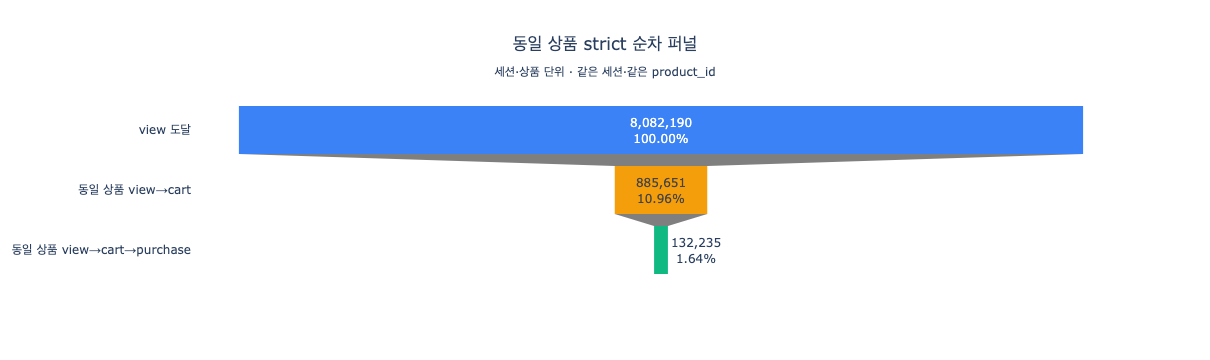

In [21]:
fig = go.Figure(go.Funnel(
    y=product_funnel['단계'],
    x=product_funnel['session_product수'],
    marker=dict(color=[color_map['view'], color_map['cart'], color_map['purchase']]),
    texttemplate='%{value:,.0f}<br>%{percentInitial:.2%}',
))
fig.update_layout(
    title=dict(
        text='동일 상품 strict 순차 퍼널<br>'
             '<sub>세션·상품 단위 · 같은 세션·같은 product_id</sub>',
        x=0.5,
        xanchor='center',
    ),
    plot_bgcolor='white',
)
fig.show()

In [22]:
product_boundary = pd.DataFrame({
    '구분': ['view 없이 cart', 'view 없이 purchase', 'view·cart 있으나 strict 순서 미확인'],
    'session_product수': [
        int(p['view없이_cart']),
        int(p['view없이_purchase']),
        int(p['view_cart있으나_순서미확인']),
    ],
})
product_boundary['전체조합대비_pct'] = (
    product_boundary['session_product수'] / int(p['session_product수']) * 100
).round(3)
cart_session_product = (
    int(p['view없이_cart']) + product_cart + int(p['view_cart있으나_순서미확인'])
)
ordered_view_cart_share = product_cart / cart_session_product * 100
print(
    f"cart 존재 session-product 중 동일 세션 선행 view 확인 = "
    f"{product_cart:,} / {cart_session_product:,} ({ordered_view_cart_share:.2f}%)"
)
print(
    f"동일 세션 선행 view 미확인 = {cart_session_product - product_cart:,} / "
    f"{cart_session_product:,} ({100 - ordered_view_cart_share:.2f}%)"
)
product_boundary

cart 존재 session-product 중 동일 세션 선행 view 확인 = 885,651 / 4,626,079 (19.14%)
동일 세션 선행 view 미확인 = 3,740,428 / 4,626,079 (80.86%)


,구분,session_product수,전체조합대비_pct
0,view 없이 cart,3439265,28.419
1,view 없이 purchase,997116,8.239
2,view·cart 있으나 strict 순서 미확인,301163,2.489


### 카테고리별 동일 상품 순차 전환

In [23]:
cat = add_funnel_rates(run('fn_product_category')) # 카테고리별 동일 상품 strict 순차 퍼널

# 기존 소표본 기준 유지: 상품 수 >= 30 AND view 도달 session-product >= 10,000
MIN_PROD, MIN_VIEW = 30, 10000
elig = cat[(cat['상품수'] >= MIN_PROD) & (cat['view_도달'] >= MIN_VIEW)].copy()
coverage = elig['view_도달'].sum() / cat['view_도달'].sum() * 100
show = [
    'category_id', '상품수', 'view_도달', 'view_cart_순차',
    'view_cart_purchase_순차', 'view_cart_전환율',
    'cart_purchase_전환율', 'view_purchase_전환율',
]

print(
    f"전체 카테고리 {len(cat):,} · "
    f"순위 대상(상품수>={MIN_PROD}, view도달>={MIN_VIEW:,}) {len(elig):,} · "
    f"view 도달 커버리지 {coverage:.2f}%"
)
top10 = elig.sort_values('view_purchase_전환율', ascending=False).head(10)[show]
bottom10 = elig.sort_values('view_purchase_전환율').head(10)[show]
print('--- 상위 10 (view→purchase 순차 전환율 %) ---')
top10.round(3)

[fn_product_category] 캐시 로드 · 514행
전체 카테고리 514 · 순위 대상(상품수>=30, view도달>=10,000) 147 · view 도달 커버리지 87.29%
--- 상위 10 (view→purchase 순차 전환율 %) ---


,category_id,상품수,view_도달,view_cart_순차,view_cart_purchase_순차,view_cart_전환율,cart_purchase_전환율,view_purchase_전환율
60,1487580006509970331,35,11051.0,2590.0,592.0,23.437,22.857,5.357
162,1487580009311764506,143,23554.0,4580.0,883.0,19.445,19.279,3.749
161,1487580009286598681,458,57602.0,10512.0,2036.0,18.249,19.368,3.535
62,1487580006551913373,64,20403.0,3690.0,699.0,18.086,18.943,3.426
479,2140803113261466607,54,14859.0,2478.0,501.0,16.677,20.218,3.372
326,1487580013858390233,128,20681.0,3291.0,677.0,15.913,20.571,3.274
158,1487580009202712597,60,11231.0,1376.0,366.0,12.252,26.599,3.259
385,1783999068909863670,170,23039.0,4173.0,742.0,18.113,17.781,3.221
250,1487580011853512836,142,13152.0,1857.0,421.0,14.120,22.671,3.201
289,1487580013011140782,72,23722.0,3381.0,729.0,14.253,21.562,3.073


In [24]:
print('--- 하위 10 (view→purchase 순차 전환율 %) ---')
bottom10.round(3)

--- 하위 10 (view→purchase 순차 전환율 %) ---


,category_id,상품수,view_도달,view_cart_순차,view_cart_purchase_순차,view_cart_전환율,cart_purchase_전환율,view_purchase_전환율
204,1487580010695884882,44,19396.0,454.0,83.0,2.341,18.282,0.428
53,1487580006300255120,110,229967.0,8913.0,1377.0,3.876,15.449,0.599
413,1891434214553813877,96,40259.0,2601.0,246.0,6.461,9.458,0.611
150,1487580008984608779,50,20118.0,943.0,141.0,4.687,14.952,0.701
468,2089259162625114209,94,31822.0,1565.0,243.0,4.918,15.527,0.764
374,1761186209054327497,88,12369.0,789.0,102.0,6.379,12.928,0.825
330,1487580013950664926,297,194403.0,10280.0,1680.0,5.288,16.342,0.864
298,1487580013229244601,216,16750.0,1329.0,153.0,7.934,11.512,0.913
199,1487580010561667147,175,40611.0,2947.0,371.0,7.257,12.589,0.914
144,1487580008800059394,506,34656.0,3682.0,321.0,10.624,8.718,0.926


### 카테고리 개선 우선순위 — 전환 갭 × 트래픽

순위 대상 147개 카테고리의 view→purchase 순차 전환율 중앙값을 기준선으로 두고, 중앙값 하회 폭 × view 도달 session-product로 상대적 기회 크기를 계산한다. 이 값은 예상 추가 구매나 개선 효과가 아니라 전환 갭과 노출 규모를 함께 보기 위한 우선순위 지표이다. `view_도달`은 session-product 단위인 반면 `mart_product.revenue`는 상품 단위·전체 관측 기간 값이므로 서로 합산하지 않고 별도 열로 제시한다.

In [25]:
cat_revenue = run('fn_product_category_revenue') # 대표 카테고리별 상품 전체 기간 revenue
cat_revenue['revenue'] = cat_revenue['revenue'].astype(float)
elig = elig.merge(
    cat_revenue[['category_id', 'revenue']], on='category_id', how='left', validate='one_to_one'
)
category_median = elig['view_purchase_전환율'].median()
elig['중앙값하회폭_pct'] = (category_median - elig['view_purchase_전환율']).clip(lower=0)
elig['기회크기_근사'] = elig['중앙값하회폭_pct'] / 100 * elig['view_도달']
assert elig['revenue'].notna().all() and elig['기회크기_근사'].ge(0).all()
priority_cols = [
    'category_id', '상품수', 'view_도달', 'view_cart_전환율',
    'cart_purchase_전환율', 'view_purchase_전환율', '중앙값하회폭_pct',
    '기회크기_근사', 'revenue',
]
priority_top10 = elig.sort_values(
    ['기회크기_근사', 'view_도달'], ascending=[False, False]
).head(10)[priority_cols]
rate_leader_idx = elig['view_purchase_전환율'].idxmax()
rate_leader_id = int(elig.loc[rate_leader_idx, 'category_id'])
print(f"순위 대상 view→purchase 전환율 중앙값: {category_median:.3f}%")
print(
    f"전환율 1위 category_id={rate_leader_id} · "
    f"view 도달 {int(elig.loc[rate_leader_idx, 'view_도달']):,} · "
    f"전환율 {elig.loc[rate_leader_idx, 'view_purchase_전환율']:.3f}% · "
    f"기회크기 근사 {elig.loc[rate_leader_idx, '기회크기_근사']:.2f}"
)
print('--- 전환 갭 × 트래픽 기준 상위 10 카테고리 ---')
priority_top10.round(3)

[fn_product_category_revenue] 캐시 로드 · 515행
순위 대상 view→purchase 전환율 중앙값: 1.753%
전환율 1위 category_id=1487580006509970331 · view 도달 11,051 · 전환율 5.357% · 기회크기 근사 0.00
--- 전환 갭 × 트래픽 기준 상위 10 카테고리 ---


,category_id,상품수,view_도달,view_cart_전환율,cart_purchase_전환율,view_purchase_전환율,중앙값하회폭_pct,기회크기_근사,revenue
22,1487580006300255120,110,229967.0,3.876,15.449,0.599,1.154,2654.080,351672.31
35,1487580007675986893,3486,355038.0,10.672,11.654,1.244,0.509,1807.443,102743.07
112,1487580013950664926,297,194403.0,5.288,16.342,0.864,0.889,1727.680,136068.61
110,1487580013841613016,1861,222470.0,7.341,15.730,1.155,0.598,1330.665,62194.62
118,1602943681873052386,233,260273.0,10.295,12.660,1.303,0.450,1170.312,186388.51
16,1487580005595612013,1332,251687.0,12.022,11.389,1.369,0.384,965.809,134047.48
7,1487580005092295511,711,332141.0,11.625,12.812,1.489,0.263,875.083,418736.06
57,1487580009051717646,200,94205.0,6.949,16.285,1.132,0.621,585.315,114698.00
24,1487580006350586771,93,92907.0,6.843,16.908,1.157,0.596,553.562,138623.97
17,1487580005671109489,1260,187084.0,12.431,11.975,1.489,0.264,494.386,108903.93


### 가격대(avg_price 구간)별 동일 상품 순차 전환

In [26]:
price = add_funnel_rates(run('fn_product_price')) # 가격대별 동일 상품 strict 순차 퍼널
price.round(3)

[fn_product_price] 캐시 로드 · 7행


,가격대,상품수,view_도달,view_cart_순차,view_cart_purchase_순차,session_product수,view_cart_전환율,cart_purchase_전환율,view_purchase_전환율
0,가격미상,620,1019.0,11.0,0.0,1719,1.079,0.000,0.000
1,0-5,28070,3957868.0,506056.0,73384.0,6852756,12.786,14.501,1.854
2,5-15,19747,2746869.0,294873.0,44166.0,3726864,10.735,14.978,1.608
3,15-30,3849,678558.0,52848.0,9302.0,791862,7.788,17.601,1.371
4,30-60,1467,352142.0,19543.0,3394.0,372739,5.550,17.367,0.964
5,60-100,349,199061.0,8097.0,1396.0,205413,4.068,17.241,0.701
6,100+,141,146673.0,4223.0,593.0,150695,2.879,14.042,0.404


### brand 결측(unknown)별 동일 상품 순차 전환

In [27]:
brand = add_funnel_rates(run('fn_product_brand')) # brand 결측 여부별 동일 상품 strict 순차 퍼널
brand.round(3)

[fn_product_brand] 캐시 로드 · 2행


,brand_구분,상품수,view_도달,view_cart_순차,view_cart_purchase_순차,session_product수,view_cart_전환율,cart_purchase_전환율,view_purchase_전환율
0,known,30908,4790674.0,512517.0,77191.0,7080035,10.698,15.061,1.611
1,unknown,23335,3291516.0,373134.0,55044.0,5022013,11.336,14.752,1.672


In [28]:
product_rate_cols = [
    'view_cart_전환율', 'cart_purchase_전환율', 'view_purchase_전환율',
]
product_rates_valid = all(
    frame[product_rate_cols].stack().between(0, 100).all()
    for frame in (comparison, cat, price, brand)
)
print(f"세션·상품 strict 전환율 0~100% 검증: {product_rates_valid}")
assert product_rates_valid

세션·상품 strict 전환율 0~100% 검증: True


### 단계별 전환율 변동 폭 종합

요일·사용자 유형·카테고리·가격대·brand에서 view→cart와 cart→purchase 전환율의 최솟값·최댓값·최댓값/최솟값 배율을 비교한다. 순위 대상 147개 카테고리는 중앙값과 IQR도 함께 확인한다. 가격대 비교에서는 순차 cart가 있으나 purchase가 0인 가격미상 구간을 제외해 0으로 나눌 때 생기는 무한 배율을 피한다.

In [29]:
def summarize_rate_spread(frame, 구분):
    rows = []
    for col, 단계 in [
        ('view_cart_전환율', 'view→cart'),
        ('cart_purchase_전환율', 'cart→purchase'),
    ]:
        s = frame[col].dropna()
        q1, q3 = s.quantile([0.25, 0.75])
        rows.append({
            '구분': 구분, '단계': 단계, '최솟값': s.min(), '최댓값': s.max(),
            '중앙값': s.median(), 'IQR': q3 - q1,
            '최대_최소배율': s.max() / s.min(),
        })
    return rows

price_known = price[price['가격대'] != '가격미상'].copy()
spread_rows = []
for frame, label in [
    (dow, '요일'), (monthly, '월'), (seg_v, '사용자 유형'),
    (elig, '카테고리 147개'),
    (price_known, '가격대(유효가격)'), (brand, 'brand'),
]:
    spread_rows.extend(summarize_rate_spread(frame, label))
rate_spread = pd.DataFrame(spread_rows)
category_spread = rate_spread[rate_spread['구분'] == '카테고리 147개'].copy()
print('--- 순위 대상 147개 카테고리 전환율 분포(%) ---')
display(category_spread.round(3))
print('--- 세그먼트별 단계 전환율 변동 폭(%) ---')
rate_spread[['구분', '단계', '최솟값', '최댓값', '최대_최소배율']].round(3)

--- 순위 대상 147개 카테고리 전환율 분포(%) ---


,구분,단계,최솟값,최댓값,중앙값,IQR,최대_최소배율
6,카테고리 147개,view→cart,2.341,23.437,11.625,3.065,10.013
7,카테고리 147개,cart→purchase,8.718,28.455,16.154,5.589,3.264


--- 세그먼트별 단계 전환율 변동 폭(%) ---


,구분,단계,최솟값,최댓값,최대_최소배율
0,요일,view→cart,15.466,18.025,1.165
1,요일,cart→purchase,12.308,15.237,1.238
2,월,view→cart,14.742,21.337,1.447
3,월,cart→purchase,10.556,15.677,1.485
4,사용자 유형,view→cart,12.198,18.204,1.492
5,사용자 유형,cart→purchase,13.037,13.902,1.066
6,카테고리 147개,view→cart,2.341,23.437,10.013
7,카테고리 147개,cart→purchase,8.718,28.455,3.264
8,가격대(유효가격),view→cart,2.879,12.786,4.441
9,가격대(유효가격),cart→purchase,14.042,17.601,1.253


> ### 섹션 결론
>
> - 동일 상품 view→cart 전환율은 10.958%로 세션 기준 16.724%보다 낮다. cart가 존재하는 4,626,079개 session-product 중 같은 세션에서 선행 view가 확인된 조합은 885,651개(19.14%)뿐이고 3,740,428개(80.86%)는 확인되지 않아, 동일 세션·동일 상품 선형 퍼널은 cart 경로의 소수 유형이다. 목록·검색 결과에서 바로 담았거나 이전 세션에서 열람했을 가능성이 있으며, 둘의 구분은 05 소관이다.
> - 순위 대상 147개 카테고리의 view→purchase 중앙값은 1.753%다. 전환 갭 × 트래픽 기준 1위는 category_id `1487580006300255120`으로, view 도달 229,967개·전환율 0.599%·중앙값 하회 폭 1.154%·기회 크기 근사 2,654.080이며 전체 기간 상품 revenue는 351,672.31이다. 반면 전환율 1위 `1487580006509970331`은 view 도달 11,051개·전환율 5.357%·기회 크기 0으로, 전환율 순위와 개선 우선순위가 다르다. 기회 크기 1위의 revenue는 7위 418,736.06보다 작아 건당 가치가 점수에 반영되지 않으며, revenue는 참고 정보일 뿐 session-product 지표와 합산하지 않는다.
> - 147개 카테고리에서 view→cart의 최대/최소 배율은 10.013배, cart→purchase는 3.264배였다. 가격대(가격미상 제외)도 각각 4.441배·1.253배로 cart 도달 전 단계의 상대적 변동이 더 컸다. 상품 구성 차이가 함께 반영되므로 가격이나 카테고리의 인과 효과로 해석하지 않는다.
> - brand known·unknown의 view→purchase 전환율은 각각 1.611%·1.672%이고, 단계별 최대/최소 배율도 view→cart 1.060배·cart→purchase 1.021배로 작았다. brand 결측 여부만으로는 개선 우선순위를 정하기 어렵다.

---
## 7. 결론

### 핵심 발견

각 구분의 세부 집단 가운데 전환율이 가장 낮은 집단과 가장 높은 집단을 비교했다. 괄호 안은 `최소 전환율~최대 전환율`이며, 배율은 `최대 전환율 ÷ 최소 전환율`이다.

| 구분 | 비교한 세부 집단 | view→cart 세그먼트 간 범위 | cart→purchase 세그먼트 간 범위 |
|---|---|---:|---:|
| 카테고리 | 분석 조건을 충족한 147개 카테고리 | 2.341%~23.437% (10.013배) | 8.718%~28.455% (3.264배) |
| 사용자 유형 | 1세션 사용자·2+세션 사용자 | 12.198%~18.204% (1.492배) | 13.037%~13.902% (1.066배) |
| 가격대 | 가격미상 제외 가격 구간 | 2.879%~12.786% (4.441배) | 14.042%~17.601% (1.253배) |
| brand | known·unknown | 10.698%~11.336% (1.060배) | 14.752%~15.061% (1.021배) |
| 요일 | 7개 요일 | 15.466%~18.025% (1.165배) | 12.308%~15.237% (1.238배) |
| 월 | 2019-10~2020-02 | 14.742%~21.337% (1.447배) | 10.556%~15.677% (1.485배) |

카테고리·사용자 유형·가격대처럼 상품 및 사용자 특성에 따른 구분에서는 view→cart의 상대적 변동이 더 크게 관찰됐다. 반면 요일과 월 같은 시간축에서는 cart→purchase의 변동이 view→cart보다 컸으며, brand는 두 단계 모두 차이가 작았다. 따라서 상품·사용자 구분에서의 개선 후보는 상대적 격차가 크게 나타난 view→cart 단계에 우선하여 찾되, 이 경향을 시간축까지 일반화하지 않는다.

- 세션 strict 순차 퍼널은 view→cart 16.72%, cart→purchase 13.75%, view→purchase 2.30%다. view→cart 미전환 3,535,326세션 중 2,819,440개(79.75%)는 유효 이벤트가 view 1개뿐이고 715,886개(20.25%)는 2개 이상 이벤트가 있다. views=1 구간도 89.56%가 단일 이벤트 세션이므로 8.431%를 탐색 깊이 자체의 전환율로 해석하지 않는다.
- 2+세션 사용자는 전체 사용자의 33.68%지만 세션의 75.92%, 순차 구매 세션의 82.96%를 차지해 활동과 순차 구매가 소수 사용자 집단에 집중됐다. 이는 관측 기간 내 집단 분류이며 재방문의 인과 효과가 아니다.
- cart가 있는 session-product 중 동일 세션·동일 상품의 선행 view가 확인된 비율은 19.14%에 그쳤다. 카테고리 개선 우선순위 1위는 전환 갭과 트래픽이 함께 큰 category_id `1487580006300255120`으로, view 도달 229,967개·view→purchase 0.599%·기회 크기 근사 2,654.080으로 나타났다.

### 정의 · 한계

- 본 결과는 같은 세션 안에서 event_time의 strict 순서를 확인한 관찰 분석이다. 세션을 넘는 view·cart·purchase와 동일 시각 이벤트의 실제 순서는 포함하지 않는다. 양끝 월은 완결 월이며 5개월 view→purchase는 2.113%-2.593%(1.227배)로 상대적으로 좁았지만, view→cart와 cart→purchase는 월별로 반대 방향 이동이 관찰됐다. 실제 프로모션·상품 및 사용자 구성 변화와 cart 기록 방식·정의 변화 가능성을 모두 배제할 수 없으며 어느 쪽도 단정하지 않는다. 01의 2020-02 가격 품질 신호와 월별 전환율 변화의 인과관계도 확인할 수 없다.
- cart·purchase 없이 remove만 관찰된 87,927세션은 이전 세션의 장바구니 상태가 이어졌을 가능성을 시사하지만, cart 로깅 누락·추적 유실도 가능한 설명이다. remove 발생 순서가 없어 장바구니 이탈로도 해석하지 않는다.
- total_events는 미전환 모집단 분해에만 사용한다. 이벤트 유형이 view·cart·remove·purchase로 모두 퍼널 행동과 연결돼 views를 사용해도 탐색량과 후속 행동 발생 여부를 완전히 분리할 수 없다. 카테고리 기회 크기는 전환 갭 × session-product view 도달의 상대 지표이며 건당 가치와 실제 개선 효과를 뜻하지 않는다. 상품 revenue는 상품 단위·전체 기간 값이고, 카테고리·브랜드도 로그에서 선택한 대표값이다.

### 개선 제안 · 후속 검증

- category_id `1487580006300255120`을 첫 카테고리 진단 후보로 두고, 해당 카테고리에서 views 11회 이상인데 cart가 없는 세션을 포함해 상품 정보·가격·검색·필터·cart UI 경로를 점검한다. 전환율 1위보다 전환 갭과 트래픽이 함께 큰 대상을 먼저 본다는 기준이며, 우선순위 점수를 성과 예측값으로 사용하지 않는다.
- 05에서는 user_id×product_id로 세션을 연결해 동일 세션 선행 view가 없는 cart 80.86%와 cart·purchase 없이 remove만 있는 87,927세션을 추적한다. 목록·검색 결과에서의 직접 cart, 이전 세션 열람·장바구니 유지, 로깅 누락을 구분하고 지연 구매·remove 이후 재담기 여부를 확인한다.
- 후속 진단에서 관찰 근거가 가장 강한 마찰이 정해지면 선택한 카테고리·행동 집단에서 상품 탐색 또는 cart 진입 경험 개선안을 A/B 테스트로 검증한다. 1차 지표는 동일 상품 view→cart 순차 전환율, 2차 지표는 purchase 전환율·revenue로 두며 유입 채널·검색 결과 노출·페이지 이탈·cart 클릭 로그를 함께 수집한다.